# Dimensionality Reduction: PCA (Principal Component Analysis)

**Dataset:** `clean_scaled_loan_data.csv`

**When to use:** When you want to **transform** the data into a new, lower-dimensional space rather than just selecting a subset of existing features.

**How it works:** PCA identifies the axes (**Principal Components**) along which the data has the **maximum variance**. It collapses the original features into these new, uncorrelated components.

> **Key difference from Feature Selection:** PCA creates _new_ features (linear combinations of originals), while feature selection keeps _existing_ features.

---


### Step 1: Setup & Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../../data/Lab5/clean_scaled_loan_data.csv')
print(f'Original shape: {df.shape}')
print(f'Number of features: {len(df.columns)}')
df.head()

Original shape: (148670, 26)
Number of features: 26


,loan_amount,term,income,Credit_Score,age,Status,loan_limit_freq,Gender_freq,approv_in_adv_freq,loan_type_freq,...,lump_sum_payment_freq,construction_type_freq,occupancy_type_freq,Secured_by_freq,total_units_freq,credit_type_freq,co-applicant_credit_type_freq,submission_of_application_freq,Region_freq,Security_Type_freq
0,-1.166980,0.425737,-0.829008,0.502357,-1.474103,1.748627,0.274622,-0.086254,0.432241,0.559687,...,0.152617,0.0149,0.275199,0.0149,0.122273,-0.032010,0.999233,0.741826,-0.099392,0.0149
1,-0.677607,0.425737,-0.314189,-1.275413,0.500437,1.748627,0.274622,0.773193,0.432241,-1.722629,...,-6.552344,0.0149,0.275199,0.0149,0.122273,-2.826994,-1.000767,0.741826,0.556135,0.0149
2,0.409890,0.425737,0.400838,1.158234,-0.815923,-0.571877,0.274622,0.773193,-2.327742,0.559687,...,0.152617,0.0149,0.275199,0.0149,0.122273,-0.032010,0.999233,0.741826,-0.099392,0.0149
3,0.681764,0.425737,0.782185,-0.973365,-0.157743,-0.571877,0.274622,0.773193,0.432241,0.559687,...,0.152617,0.0149,0.275199,0.0149,0.122273,-0.032010,0.999233,-1.349842,0.556135,0.0149
4,1.986759,0.425737,0.553377,-0.843916,-1.474103,-0.571877,0.274622,0.599543,-2.327742,0.559687,...,0.152617,0.0149,0.275199,0.0149,0.122273,0.245329,-1.000767,-1.349842,0.556135,0.0149


### Step 2: Apply PCA

Reduce to 10 principal components.


In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
df_pca = pca.fit_transform(df)

print(f'Reduced from {len(df.columns)} to {pca.n_components_} components')
df_pca

Reduced from 26 to 10 components


array([[-0.05769996, -0.94040287, -0.08562992, ..., -1.12806348,
         0.88630038, -0.48270974],
       [-0.18863257, -2.95507928, -4.80555838, ..., -0.03090938,
         1.31442691,  3.08048023],
       [ 0.02962368,  0.50510684,  0.27869672, ..., -1.06144125,
         0.44793471, -2.17828611],
       ...,
       [ 0.10235287,  1.41705745,  0.51749011, ...,  1.22161137,
         0.77549989, -0.58340427],
       [ 0.03725973, -0.6693399 ,  0.92614548, ...,  0.23519091,
        -0.3117392 , -0.26757882],
       [ 0.07475283,  0.71064736,  1.75827372, ..., -0.49743835,
        -0.85148755, -0.3433011 ]], shape=(148670, 10))

### Step 3: Visualize Explained Variance

Each bar shows how much variance that principal component captures.


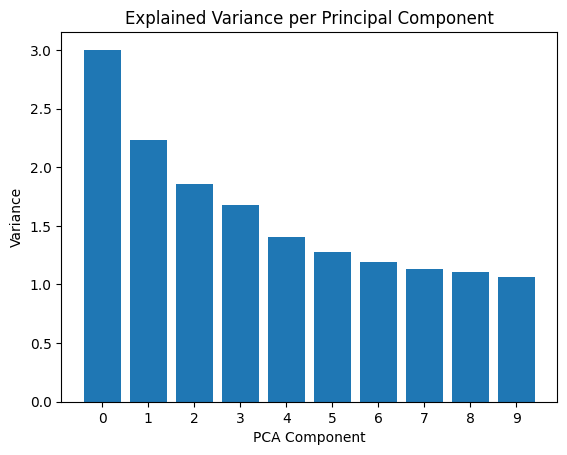


Total explained variance ratio: 0.6131
Per component: ['0.1155', '0.0859', '0.0715', '0.0644', '0.0539', '0.0492', '0.0459', '0.0435', '0.0425', '0.0408']


In [3]:
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_)
plt.xlabel('PCA Component')
plt.ylabel('Variance')
plt.title('Explained Variance per Principal Component')
plt.xticks(features)
plt.show()

print(f'\nTotal explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}')
print('Per component:', [f'{r:.4f}' for r in pca.explained_variance_ratio_])

### Step 4: Create PCA DataFrame


In [4]:
df_pca_result = pd.DataFrame(
    data=df_pca,
    columns=['PC' + str(i) for i in range(1, pca.n_components_ + 1)]
)
df_pca_result.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-0.057700,-0.940403,-0.085630,0.532582,0.555039,-1.237076,0.951001,-1.128063,0.886300,-0.482710
1,-0.188633,-2.955079,-4.805558,-0.483737,0.962508,-0.286020,1.535738,-0.030909,1.314427,3.080480
2,0.029624,0.505107,0.278697,0.006569,0.427506,-1.554538,-1.174958,-1.061441,0.447935,-2.178286
3,0.097994,1.612159,0.586917,-0.548512,-0.018854,0.481891,0.845643,0.128393,0.195610,-0.007720
4,0.129793,2.693596,-0.298248,-1.439249,0.455319,-0.594937,-0.822152,-1.107136,1.824771,-0.071856
